<a href="https://colab.research.google.com/github/rogernogueira/caam/blob/main/covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier


In [85]:
df  = pd.read_csv('https://gist.githubusercontent.com/rogernogueira/73703e7ef5aefe4b342d9bf711bd9fe5/raw/d971ef5c116e7e3bff39802a88aa1a9d43e8e02c/covid.csv')

In [86]:
df = df.iloc[:60000,:]

In [87]:
df.keys()

Index(['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'DATE_DIED', 'INTUBED',
       'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
       'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
       'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU'],
      dtype='object')

In [88]:
df['INTUBED'].value_counts()

,count
INTUBED,
2,24517
97,18858
1,15674
99,951


In [89]:
df = df[df['INTUBED'] <=2]

In [90]:
df  = df[['PNEUMONIA','DIABETES','ASTHMA','INMSUPR','HIPERTENSION', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC','TOBACCO' , 'INTUBED' ]]

In [92]:
df['ASTHMA'].value_counts()


,count
ASTHMA,
2,39314
1,765
98,112


In [93]:
for col in df.keys():
  df = df[df[col]<=2]

  #df[col] = df[col'].apply(lambda x: 0 if x == 2 else 1)

In [94]:
for col in df.keys():
  df[col] = df[col].apply(lambda x: 0 if x == 2 else 1)


In [95]:
df

,PNEUMONIA,DIABETES,ASTHMA,INMSUPR,HIPERTENSION,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,INTUBED
2,0,1,0,0,0,0,0,0,0,1
5,1,0,0,0,0,0,0,0,0,0
8,0,1,0,0,1,0,1,0,0,0
9,0,0,0,0,0,0,0,0,0,0
11,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
59971,1,0,0,0,0,0,0,0,0,0
59987,0,0,0,0,0,0,0,0,0,0
59990,0,0,0,0,0,0,1,0,0,0
59995,1,0,0,0,1,0,0,0,0,0


<Axes: xlabel='INTUBED', ylabel='count'>

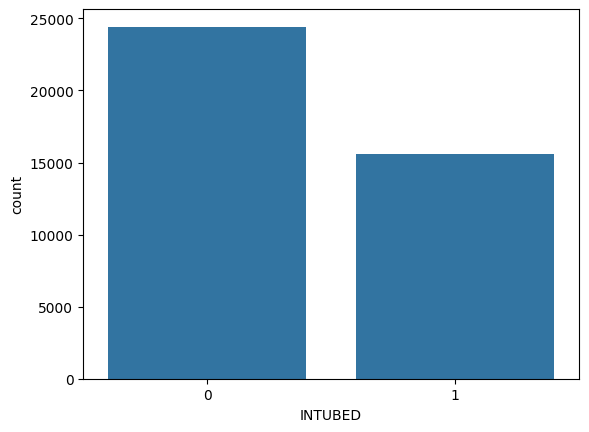

In [96]:
sns.countplot(x='INTUBED', data=df)

In [107]:
df['INTUBED'].value_counts()

,count
INTUBED,
0,24420
1,15616


In [97]:
y = df['INTUBED']
X = df.drop(columns=['INTUBED'])

In [98]:
X

,PNEUMONIA,DIABETES,ASTHMA,INMSUPR,HIPERTENSION,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO
2,0,1,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0
8,0,1,0,0,1,0,1,0,0
9,0,0,0,0,0,0,0,0,0
11,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
59971,1,0,0,0,0,0,0,0,0
59987,0,0,0,0,0,0,0,0,0
59990,0,0,0,0,0,0,1,0,0
59995,1,0,0,0,1,0,0,0,0


In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [100]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [101]:
y_pred = model.predict(X_test)

In [102]:
acurracy = accuracy_score(y_test, y_pred)

In [103]:
acurracy

0.6036966114395138

In [104]:
precision = precision_score(y_test, y_pred)
precision


0.43636363636363634

In [105]:
recall = recall_score(y_test, y_pred)
recall

0.02028740490278952